In [ ]:
import pandas as pd

df = pd.read_csv("superstore.csv")

df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [ ]:
df.shape

(51290, 27)

In [ ]:
df.isnull().sum()

,0
Category,0
City,0
Country,0
Customer.ID,0
Customer.Name,0
Discount,0
Market,0
记录数,0
Order.Date,0
Order.ID,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Category,object
City,object
Country,object
Customer.ID,object
Customer.Name,object
Discount,float64
Market,object
记录数,int64
Order.Date,object
Order.ID,object


In [ ]:
# Converting date columns into proper datetime format
df["Order.Date"] = pd.to_datetime(df["Order.Date"], dayfirst=True)
df["Ship.Date"] = pd.to_datetime(df["Ship.Date"], dayfirst=True)

# Checking the new data types
df[["Order.Date", "Ship.Date"]].dtypes

,0
Order.Date,datetime64[ns]
Ship.Date,datetime64[ns]


In [ ]:
# Summary statistics for numeric columns
df[["Sales", "Profit", "Discount", "Quantity"]].describe()

,Sales,Profit,Discount,Quantity
count,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,28.610982,0.142908,3.476545
std,487.567175,174.340972,0.212280,2.278766
min,0.000000,-6599.978000,0.000000,1.000000
25%,31.000000,0.000000,0.000000,2.000000
50%,85.000000,9.240000,0.000000,3.000000
75%,251.000000,36.810000,0.200000,5.000000
max,22638.000000,8399.976000,0.850000,14.000000


<Axes: >

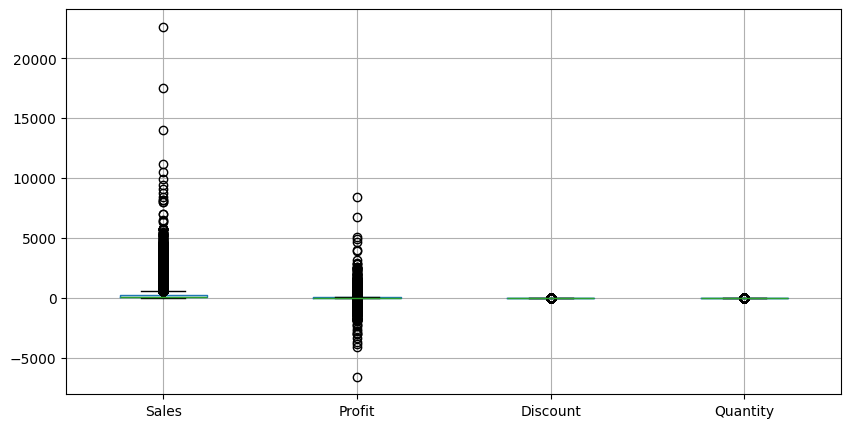

In [ ]:
df.boxplot(column=["Sales", "Profit", "Discount", "Quantity"], figsize=(10,5))


In [ ]:
# Create processed dataset
processed_df = df.copy()

# Save cleaned dataset
processed_df.to_csv("Processed_Superstore.csv", index=False)

print("Processed dataset created successfully.")

Processed dataset created successfully.


In [ ]:
# Category-wise Sales and Profit
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)

category_summary

,Sales,Profit
Category,,
Technology,4744691,663778.73318
Furniture,4110884,285204.72380
Office Supplies,3787330,518473.83430


In [ ]:
# Region-wise Sales and Profit
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)

region_summary

,Sales,Profit
Region,,
Central,2822399,311403.98164
South,1600960,140355.76618
North,1248192,194597.95252
Oceania,1100207,120089.11200
Southeast Asia,884438,17852.32900
North Asia,848349,165578.42100
EMEA,806184,43897.97100
Africa,783776,88871.63100
Central Asia,752839,132480.18700


In [ ]:
# Discount vs Profit
discount_profit = df.groupby("Discount")[["Sales", "Profit"]].mean().sort_values(by="Discount")

discount_profit.head(10)
discount_profit.tail(10)

,Sales,Profit
Discount,,
0.470,115.078621,-42.982420
0.500,198.496632,-97.140158
0.550,630.800000,-315.067200
0.570,678.666667,-526.129000
0.600,92.016949,-81.732147
0.602,216.391304,-213.279085
0.650,387.058824,-365.997971
0.700,78.258679,-104.339576
0.800,64.753165,-122.203244


In [ ]:
# Segment-wise Sales and Profit
segment_summary = df.groupby("Segment")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)

segment_summary

,Sales,Profit
Segment,,
Consumer,6508141,749239.78206
Corporate,3824808,441208.32866
Home Office,2309956,277009.18056


In [ ]:
# Reload dataset
import pandas as pd

df = pd.read_csv("superstore.csv")

# Automatically detect mixed date format
df["Order.Date"] = pd.to_datetime(df["Order.Date"], format="mixed", errors="coerce")
df["Ship.Date"] = pd.to_datetime(df["Ship.Date"], format="mixed", errors="coerce")

# Check if dates converted correctly
print(df[["Order.Date", "Ship.Date"]].head())
print(df["Order.Date"].isnull().sum())


  Order.Date  Ship.Date
0 2026-09-24 2026-09-24
1 2026-09-24 2026-09-24
2 2026-09-24 2026-09-24
3 2026-09-24 2026-09-24
4 2026-09-24 2026-09-24
0


In [ ]:
import pandas as pd

# Raw dataset reading again
raw_df = pd.read_csv("superstore.csv", dtype=str)

# first 1o original rows
raw_df["Order.Date"].head(10)

,Order.Date
0,00:00.0
1,00:00.0
2,00:00.0
3,00:00.0
4,00:00.0
5,00:00.0
6,00:00.0
7,00:00.0
8,00:00.0
9,00:00.0


In [ ]:
# Dataset column checck
print(df.columns.tolist())

# first row data
df.iloc[0]

['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum']


,0
Category,Office Supplies
City,Los Angeles
Country,United States
Customer.ID,LS-172304
Customer.Name,Lycoris Saunders
Discount,0.0
Market,US
记录数,1
Order.Date,2026-09-24 00:00:00
Order.ID,CA-2011-130813


In [ ]:
# Year-wise Sales and Profit
yearly_sales = df.groupby("Year")[["Sales", "Profit"]].sum().sort_index()

yearly_sales

,Sales,Profit
Year,,
2011,2259511,248940.81154
2012,2677493,307415.27910
2013,3405860,406935.23018
2014,4300041,504165.97046
